## Project Summary

This project forecasts weekly demand for a single SKU (Mantecadas Vainilla,
Producto_ID 1240) from Bimbo's inventory dataset, reduced from 74M rows of
raw transaction data to 2.15M rows for the target product across weeks 3-9.
The project's goal was not to achieve a competition-grade score, but to
demonstrate disciplined time-series ML workflow on transactional data —
specifically, feature engineering at high cardinality, leakage-safe
aggregations, and honest model comparison.

**Final results:**

| Model | Val RMSLE | Notes |
|-------|-----------|-------|
| Global mean baseline | 0.676 | floor |
| Client-mean baseline | 0.512 | groupby lookup, no model |
| Ridge (raw features) | 0.550 | below baseline — shape mismatch |
| Ridge (log-transformed features) | 0.496 | matched tree performance |
| LightGBM (default) | 0.495 | |
| LightGBM (tuned) | 0.498 | tuning confirmed feature ceiling |

All three properly-configured models converged within 0.003 RMSLE of each
other, establishing a clear feature ceiling around 0.495.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_log_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [ ]:

# @title Dataset Configuration & Dtypes { display-mode: "form" }import seaborn as sns

# path = "/content/drive/MyDrive/python/projects /Inventory Management/train.csv"
# product_id = 1240   # Mantecadas Vainilla 4p 125g BIM
# size = 500000        # bigger chunks = fewer iterations; tune if RAM is tight

# Optional: dtype hints to keep memory down. Bimbo train.csv columns are:
# Semana, Agencia_ID, Canal_ID, Ruta_SAK, Cliente_ID, Producto_ID,
# Venta_uni_hoy, Venta_hoy, Dev_uni_proxima, Dev_proxima, Demanda_uni_equil
# dtypes = {"Semana": "int8",
#    "Agencia_ID": "int32",
#   "Canal_ID": "int8",
#    "Ruta_SAK": "int32",
#    "Cliente_ID": "int32",
#    "Producto_ID": "int32",
#    "Venta_uni_hoy": "int32",
#    "Venta_hoy": "float32",
#    "Dev_uni_proxima": "int32",
#    "Dev_proxima": "float32",
#    "Demanda_uni_equil": "int32" }

# filtered_chunks = []
# total_rows_scanned = 0
# matched_rows = 0

# reader = pd.read_csv(path, chunksize= size, dtype=dtypes)

# for i, chunk in enumerate(reader):
    # total_rows_scanned += len(chunk)
    # hits = chunk[chunk["Producto_ID"] == product_id]
    # if len(hits) > 0:
        # filtered_chunks.append(hits)
        # matched_rows += len(hits)
    #if (i + 1) % 10 == 0:
        #print(f"Chunk {i+1:>3} | scanned: {total_rows_scanned:>12,} | matched so far: {matched_rows:>9,}")

# df = pd.concat(filtered_chunks, ignore_index=True)
# print(f"\nDone. Total scanned: {total_rows_scanned:,} | Final df shape: {df.shape}")
# print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Quick sanity check
# print("\nWeeks present:", sorted(df['Semana'].unique()))
# print("Unique stores (Cliente_ID):", df['Cliente_ID'].nunique())
# print("Unique agencies:", df['Agencia_ID'].nunique())
# print(df.head())

# Save so you don't have to re-scan train.csv next time
# df.to_csv("/content/drive/MyDrive/python/projects /Inventory Management/mantecadas_1240.csv", index=False)
# print("\nSaved filtered df to mantecadas_1240.csv")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/python/projects /Inventory Management/mantecadas_1240.csv")

In [ ]:
df.head()

,Semana,Agencia_ID,Canal_ID,Ruta_SAK,Cliente_ID,Producto_ID,Venta_uni_hoy,Venta_hoy,Dev_uni_proxima,Dev_proxima,Demanda_uni_equil
0,3,1110,7,3301,15766,1240,4,33.52,0,0.0,4
1,3,1110,7,3301,73589,1240,2,16.76,0,0.0,2
2,3,1110,7,3301,73650,1240,3,25.14,0,0.0,3
3,3,1110,7,3301,73838,1240,6,50.28,0,0.0,6
4,3,1110,7,3301,73844,1240,2,16.76,0,0.0,2


In [ ]:
sales = df.copy()

In [ ]:
sales = df.copy()

rename_map = {
    "Semana":            "week_num",
    "Agencia_ID":        "depot_id",
    "Canal_ID":          "channel_id",
    "Ruta_SAK":          "route_id",
    "Cliente_ID":        "client_id",
    "Producto_ID":       "product_id",
    "Venta_uni_hoy":     "sales_units",
    "Venta_hoy":         "sales_pesos",
    "Dev_uni_proxima":   "return_units",
    "Dev_proxima":       "return_pesos",
    "Demanda_uni_equil": "adj_demand",   # the target
}
sales = sales.rename(columns=rename_map)


In [ ]:
# since we are dealing with a single product here, we can drop the product_id column

sales = sales.drop(columns = ["product_id"], axis = 1)
sales.head()

,week_num,depot_id,channel_id,route_id,client_id,sales_units,sales_pesos,return_units,return_pesos,adj_demand
0,3,1110,7,3301,15766,4,33.52,0,0.0,4
1,3,1110,7,3301,73589,2,16.76,0,0.0,2
2,3,1110,7,3301,73650,3,25.14,0,0.0,3
3,3,1110,7,3301,73838,6,50.28,0,0.0,6
4,3,1110,7,3301,73844,2,16.76,0,0.0,2


# **Understanding Data**

In [ ]:
tgt_col = "adj_demand"
num_cols = ["sales_units", "sales_pesos", "return_units", "return_pesos"]
cat_cols = ["depot_id","channel_id", "route_id", "client_id"]
time_id = "week_num"

In [ ]:
sales.isna().sum()

# no missing values

,0
week_num,0
depot_id,0
channel_id,0
route_id,0
client_id,0
sales_units,0
sales_pesos,0
return_units,0
return_pesos,0
adj_demand,0


In [ ]:
# unique values across cat_cols

for col in cat_cols:
  print(f" Unique values in {col} : {len(sales[col].unique())}")

# huge number of clients
# distribution channels/centers  - 376
# making observation for route_id and client_id through tables is going to be difficult due to high count

 Unique values in depot_id : 376
 Unique values in channel_id : 8
 Unique values in route_id : 818
 Unique values in client_id : 521786


In [ ]:
sales.groupby("week_num")[["sales_units", "return_units", "adj_demand"]].agg(["mean", "sum", "count", "std"]).round(2)


sales_units                         return_units                 \
                mean      sum   count    std         mean    sum   count   
week_num                                                                   
3               5.84  1914821  327755  13.01         0.06  20965  327755   
4               5.87  1857075  316611  13.43         0.08  25425  316611   
5               5.84  1796596  307740  13.59         0.09  26840  307740   
6               5.73  1738051  303221  12.41         0.10  31356  303221   
7               5.66  1730712  305536  12.18         0.10  31656  305536   
8               5.56  1649634  296479  12.00         0.11  31510  296479   
9               5.62  1626124  289313  12.40         0.10  27768  289313   

               adj_demand                          
           std       mean      sum   count    std  
week_num                                           
3         1.30       5.79  1899139  327755  12.66  
4         1.40       5.81  1838156  316611  13.02  
5         1.43       5.77  1776614  307740  13.16  
6         1.78       5.65  1714658  303221  11.88  
7         1.59       5.59  1707374  305536  11.69  
8         1.75       5.49  1626317  296479  11.50  
9         1.42       5.55  1604987  289313  11.97

Across week
- the sales units is decreasing but return units are increasing
- the mean demand across weeks almost uniform(small variance) - we are supplying less to less stores.

In a week
- std is almost double of mean - high variance in demand across the stores.

In [ ]:
sales.groupby(["channel_id", "week_num"])[["sales_units", "return_units", "adj_demand"]].agg(["mean", "sum", "count", "std"]).round(2).head(10)

sales_units                         return_units         \
                           mean      sum   count    std         mean    sum   
channel_id week_num                                                           
1          3               5.14  1584153  307954   6.27         0.04  13318   
           4               5.15  1529655  296764   7.22         0.05  16234   
           5               5.07  1463213  288825   6.90         0.06  17369   
           6               5.05  1439349  284780   7.26         0.07  19673   
           7               5.00  1431998  286576   6.88         0.07  20955   
           8               4.92  1369121  278230   6.99         0.07  20379   
           9               4.90  1328730  271031   7.46         0.07  18674   
2          3              21.21      912      43  56.31         0.07      3   
           4              27.96      671      24  44.03         1.50     36   
           5              32.63      620      19  69.30         3.16     60   

                                  adj_demand                          
                      count   std       mean      sum   count    std  
channel_id week_num                                                   
1          3         307954  0.86       5.11  1574227  307954   6.26  
           4         296764  0.78       5.12  1517989  296764   7.22  
           5         288825  0.80       5.02  1450806  288825   6.90  
           6         284780  1.02       5.01  1425411  284780   7.25  
           7         286576  0.82       4.94  1417006  286576   6.87  
           8         278230  0.77       4.87  1354590  278230   6.98  
           9         271031  0.71       4.85  1314979  271031   7.46  
2          3             43  0.46      21.14      909      43  56.30  
           4             24  4.27      27.12      651      24  44.21  
           5             19  7.76      31.37      596      19  69.57

Across week
- the demand is almost uniform(mean values)
- selling less to less stores but returns increasings - same pattern as above



Across the channels
- the demand varies (mean)

In [ ]:
sales[num_cols].describe().round(2)


,sales_units,sales_pesos,return_units,return_pesos
count,2146655.00,2146655.00,2146655.00,2146655.00
mean,5.74,48.77,0.09,0.84
std,12.74,124.47,1.53,15.78
min,0.00,0.00,0.00,0.00
25%,2.00,16.76,0.00,0.00
50%,4.00,33.52,0.00,0.00
75%,6.00,50.28,0.00,0.00
max,1815.00,16153.50,360.00,3521.87


return_units - 75% of the data is 0.


sales units
- 75% of the data is under 6.
- Mean > Median.
- expect a right skewed data.

In [ ]:
client_weeks = sales.groupby("client_id")["week_num"].nunique()

print((client_weeks.value_counts(normalize = True)*100).round(2).sort_index(ascending = False))

# is the client placing ordering every week?

sales["client_loyalty"] = sales.groupby("client_id")["week_num"].transform("nunique")

week_num
7    21.53
6     7.36
5    16.58
4    11.79
3    14.61
2    13.90
1    14.23
Name: proportion, dtype: float64


Order frequency/week by clients
- only 21% of the clients order every week.
- around 42% of clients order less than 3 times per week.

In [ ]:
sales["cost_unit"] = sales["sales_pesos"]/sales["sales_units"]

print(f"cost/unit : {(sales["cost_unit"].value_counts(normalize = True, ascending = False)*100).round(4).cumsum()}")
print("\n")
print(f"cost/unit analysis : {sales["cost_unit"].describe().round(2)}")

dummy = sales.copy()

dummy["half"] = np.where(dummy["cost_unit"] < 5, 1, 0)

diff = dummy.groupby(["client_id"]).agg(max_price = ("cost_unit", "max"),min_price = ("cost_unit", "min") ).reset_index()

diff["diff"] = (diff["max_price"] - diff["min_price"]).round(2)

print(diff.loc[ diff["diff"] > 1])
print("\n")
print(diff[(diff['diff'] <= 1) & (diff['max_price'] < 5.0)])

sales[sales["cost_unit"] == 0]


cost/unit : cost_unit
8.380000    76.3450
8.380000    93.9121
8.400000    96.7710
9.070000    98.9776
8.400000    99.2194
             ...   
4.290714    99.9971
4.301733    99.9971
4.278901    99.9971
4.430000    99.9971
4.965294    99.9971
Name: proportion, Length: 100, dtype: float64


cost/unit analysis : count    2143786.00
mean           8.40
std            0.15
min            3.65
25%            8.38
50%            8.38
75%            8.38
max           11.11
Name: cost_unit, dtype: float64
         client_id  max_price  min_price  diff
202038     1003729  11.110000   8.380000  2.73
333704     2158489   5.210000   3.650000  1.56
338053     2186302   8.380000   4.910000  3.47
353093     2284474   5.210000   3.809184  1.40
363866     2354188   8.380000   4.731935  3.65
379982     2460792   8.380000   4.598235  3.78
439868     4425638   8.380000   3.650000  4.73
449738     4475354   8.380000   6.110000  2.27
470872     4569474   5.210000   3.650000  1.56
473309     4579903   5.2100

,week_num,depot_id,channel_id,route_id,client_id,sales_units,sales_pesos,return_units,return_pesos,adj_demand,client_loyalty,cost_unit


In [ ]:
sales.head()

,week_num,depot_id,channel_id,route_id,client_id,sales_units,sales_pesos,return_units,return_pesos,adj_demand,client_loyalty,cost_unit
0,3,1110,7,3301,15766,4,33.52,0,0.0,4,5,8.38
1,3,1110,7,3301,73589,2,16.76,0,0.0,2,5,8.38
2,3,1110,7,3301,73650,3,25.14,0,0.0,3,7,8.38
3,3,1110,7,3301,73838,6,50.28,0,0.0,6,7,8.38
4,3,1110,7,3301,73844,2,16.76,0,0.0,2,7,8.38


In [ ]:
sales = sales.sort_values(['client_id', 'week_num']).reset_index(drop=True)

conditions = [
    (sales["cost_unit"] < 5.0),                               # Deep wholesale
    (sales["cost_unit"] >= 5.0) & (sales["cost_unit"] < 8.37), # Clear promotions
    (sales["cost_unit"] >= 8.37) & (sales["cost_unit"] < 8.50), # The "8.38" Anchor
    (sales["cost_unit"] >= 8.50)                              # Surcharges/Premium
]

choices = ["wholesale", "discount", "standard", "premium"]

sales["price_segment"] = np.select(conditions, choices, default="unknown")

SEGMENT_TYPICAL_PRICE = {
    'wholesale': 3.65,
    'discount':  5.21,
    'standard':  8.38,
    'premium':   9.07,
}

# === Promo flag ===

sales['is_promo'] = ((sales['cost_unit'] < (8.38*0.90))).astype('int8')

# === Lag feature: was the client on promo exactly one week ago? ===
# Handles client sparsity: only counts as "last week" if the previous
# appearance was exactly week_num - 1, not just the previous row.
sales['_prev_week'] = sales.groupby('client_id')['week_num'].shift(1)
sales['_prev_promo'] = sales.groupby('client_id')['is_promo'].shift(1)

sales['promo_last_week'] = np.where(
    sales['week_num'] - sales['_prev_week'] == 1,
    sales['_prev_promo'],
    0
).astype('int8')

sales = sales.drop(columns=['_prev_week', '_prev_promo'])

Missing values in Cost_unit - 2869


<Axes: xlabel='sales_units', ylabel='return_units'>

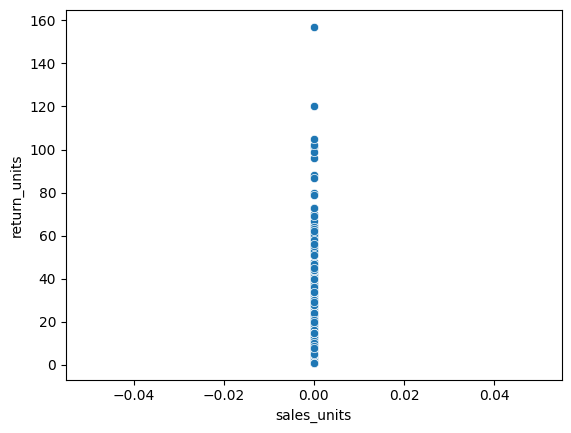

In [ ]:
unknown_segment = sales[sales["price_segment"] == "unknown"]

print(f"Missing values in Cost_unit - {sales["cost_unit"].isna().sum()}")

sns.scatterplot(unknown_segment, x = "sales_units", y = "return_units")

# encountering unknown segment in the sales df, where sales_unit == 0, meaning \
# for the client entry - no sales occured but expired product was returned.

Unknown Segment -
- "Filled with list price; affects 0.13% of rows; alternative per-client expanding-window fill considered but rejected as not cost-effective at this scale."

Remaining NaN in cost_unit: 0


<Axes: xlabel='price_segment', ylabel='sales_units'>

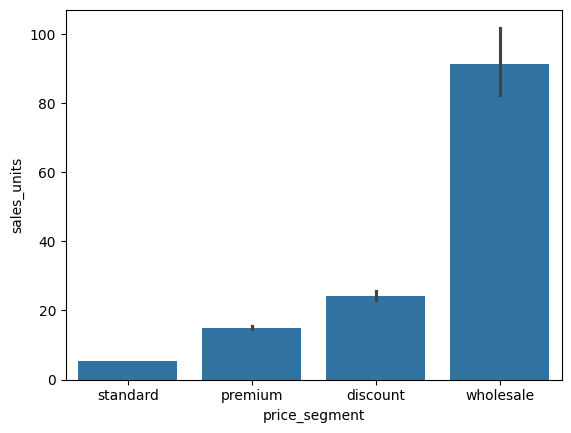

In [ ]:
sales["cost_unit"] = sales["cost_unit"].fillna(8.38)

print(f"Remaining NaN in cost_unit: {sales['cost_unit'].isna().sum()}")

# 2. Re-run the segmentation logic so the new 8.38 prices get tagged as "standard"
conditions = [
    (sales["cost_unit"] < 5.0),
    (sales["cost_unit"] >= 5.0) & (sales["cost_unit"] < 8.37),
    (sales["cost_unit"] >= 8.37) & (sales["cost_unit"] < 8.50),
    (sales["cost_unit"] >= 8.50)
]
choices = ["wholesale", "discount", "standard", "premium"]
sales["price_segment"] = np.select(conditions, choices, default="unknown")

sns.barplot(sales, x = "price_segment", y = "sales_units")

# no missing values in price_segment now

Cost/unit
- 96% of the time the product is sold at 8.40 pesos.
- Client were offered discounts - either in same week or different week.
- There are clients who are continously offered lower prices than other 96%
- client id - 9999999 and 2015152015 - needs further more research - are the point true or error - we may need to drop them from the df

In [ ]:
print(f"adjusted demand stats : {sales[tgt_col].describe().round(2)}")
print("\n")
print(f"Count(adj_demand == 0) : {sales.loc[sales["adj_demand"] == 0]["adj_demand"].value_counts().values}")

(sales.loc[sales["adj_demand"] == 0]["client_id"].value_counts().head(10)).sort_values()

adjusted demand stats : count    2146655.00
mean           5.67
std           12.30
min            0.00
25%            2.00
50%            4.00
75%            6.00
max         1815.00
Name: adj_demand, dtype: float64


Count(adj_demand == 0) : [19795]


,count
client_id,
1112419,7
1685667,7
29625,7
1112380,10
653017,14
652901,14
653378,34
653058,42
652940,43


Target Variable - adjusted_demand
- Mean > Median
- min and max values - large gap
- around less than 75% of the values are less than mean.
- 75% of values lies within 6, yet the std dev is 12.30
- expect a right skewed distribution.
- we have min-adjusted demand ==0, meaning we have rows where sales < returned


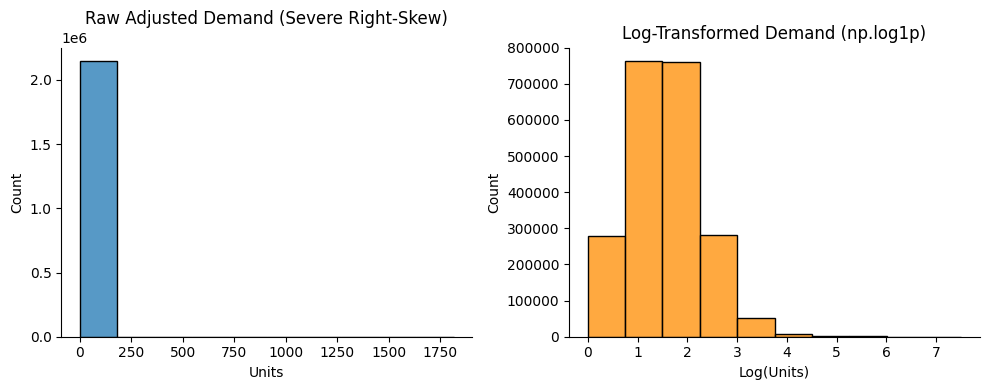

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# Pass the specific axis to the 'ax' parameter
sns.histplot(sales["adj_demand"], bins=10, ax=axes[0])
axes[0].set_title("Raw Adjusted Demand (Severe Right-Skew)")
axes[0].set_xlabel("Units")

# Apply the log transformation directly to the data passed into Seaborn
sns.histplot(np.log1p(sales["adj_demand"]), bins=10, ax=axes[1], color="darkorange")
axes[1].set_title("Log-Transformed Demand (np.log1p)")
axes[1].set_xlabel("Log(Units)")

sns.despine() # Cleans up the top and right borders
plt.tight_layout()
plt.show()

Adjusted demand
- high right skewed.
- Applying log scale - normalizes the demand -

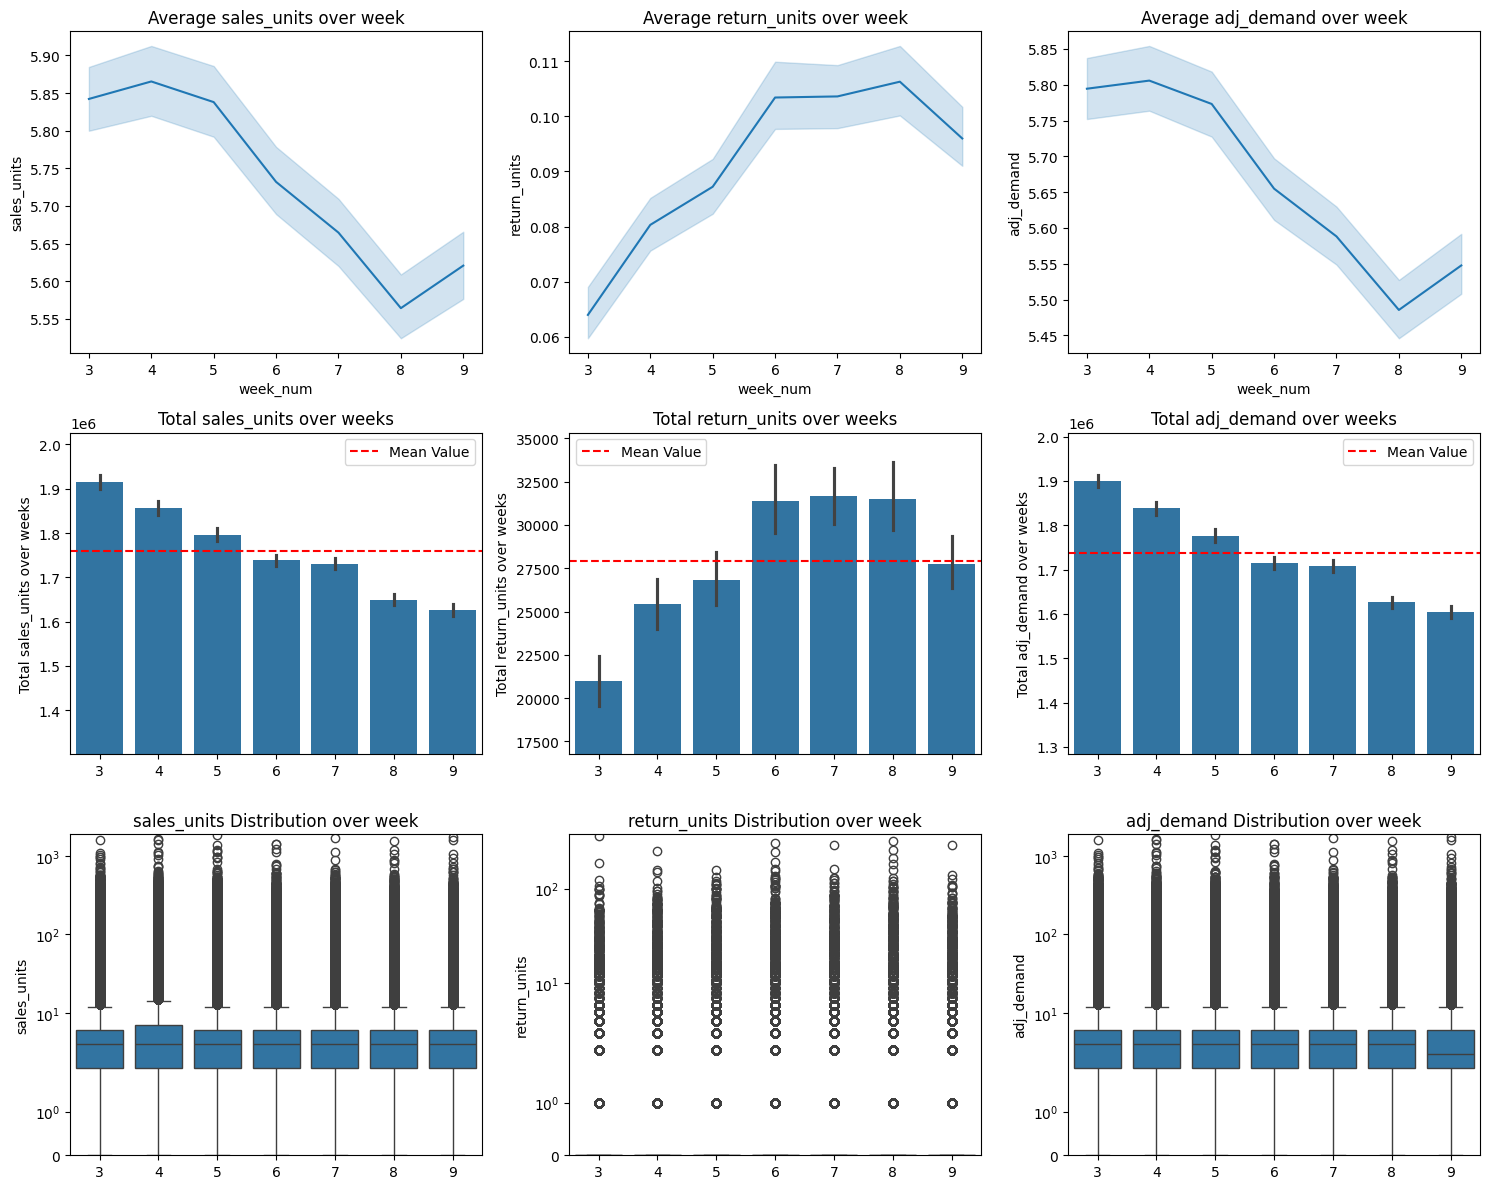

In [ ]:
cols = ["sales_units", "return_units", "adj_demand"]

fig, axes = plt.subplots(ncols = 3, nrows = 3, figsize = (15,12))

axes = axes.flatten()

for i, col in enumerate(cols):
  sns.lineplot(sales, y = col , x = "week_num", ax = axes[i])
  axes[i].set_title(f"Average {col} over week")

for i, col in enumerate(cols):
  i = i+3
  sns.barplot(sales, x= "week_num", y = col, estimator = "sum", ax = axes[i])
  axes[i].set_title(f"Total {col} over weeks")
  axes[i].axhline(sales.groupby("week_num")[col].sum().mean(), linestyle = "--", color = "red",
                  label = "Mean Value")
  axes[i].set_xlabel("")
  axes[i].set_ylabel(f"Total {col} over weeks")
  axes[i].set_ylim(bottom = (sales.groupby("week_num")[col].sum().min())*0.80)
  axes[i].legend()

for i, col in enumerate(cols):
  i = i + 6
  sns.boxplot(sales, y = col, x = "week_num", ax = axes[i])
  axes[i].set_title(f"{col} Distribution over week")
  axes[i].set_xlabel("")
  axes[i].set_yscale("symlog")
  axes[i].set_ylim(bottom = 0)

plt.tight_layout(h_pad = 1, w_pad = 1)
plt.show()


Demand VS Returns vs Adjusted demand
- Demand decreases over the week
- returns increases over the week
- Week 6,7 and 8 - below mean sales, but above mean returns---> High order volume carried over the previous weeks, a excess safety net carried by clients
- Outliers across the weeks -

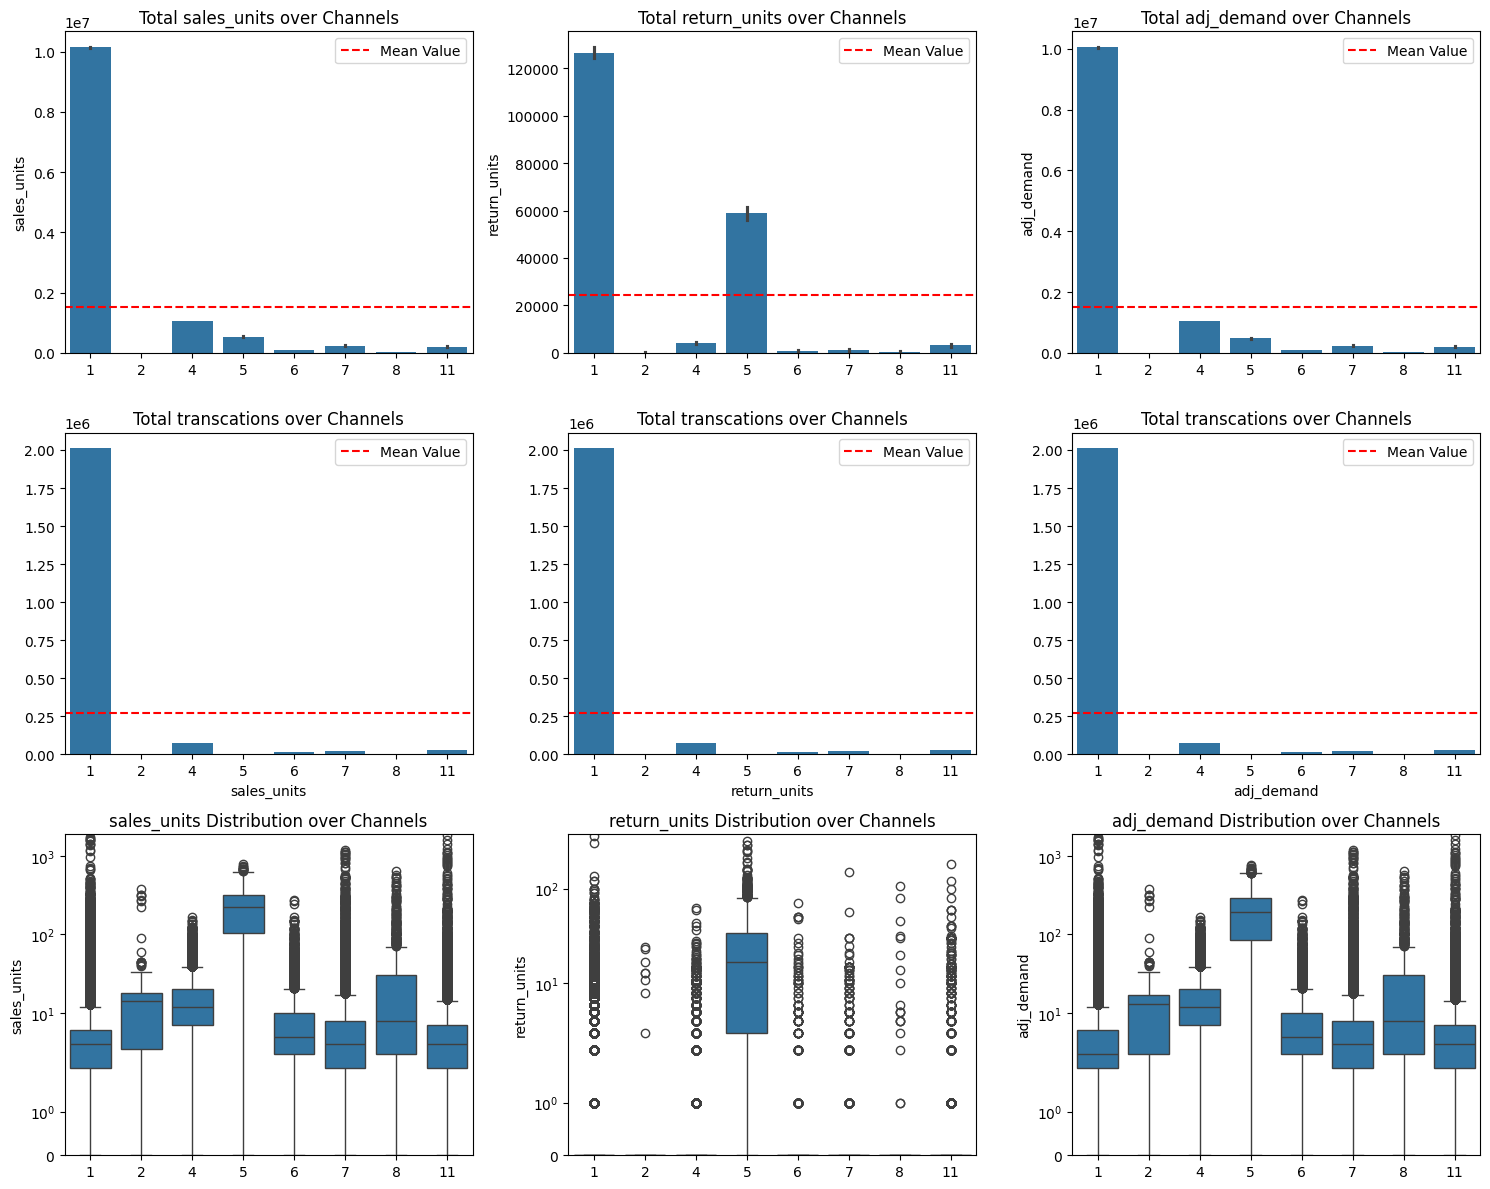

In [ ]:
fig, axes = plt.subplots(ncols = 3, nrows = 3, figsize = (15,12))

axes = axes.flatten()

for i, col in enumerate(cols):
  sns.barplot(sales, y = col , x = "channel_id", ax = axes[i], estimator = "sum")
  axes[i].set_title(f"Total {col} over Channels")
  axes[i].axhline( sales.groupby("channel_id")[col].sum().mean(), linestyle = "--",
                  color = "red", label = "Mean Value")
  axes[i].legend()
  axes[i].set_xlabel("")

for i, col in enumerate(cols):
  i = i+3
  sns.barplot(sales, y = col,x = "channel_id" ,ax = axes[i], estimator = len)
  axes[i].set_title(f"Total transcations over Channels")
  axes[i].axhline(sales.groupby("channel_id")[col].count().mean(), linestyle = "--", color = "red",
                  label = "Mean Value")
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("")
  axes[i].legend()

for i, col in enumerate(cols):
  i = i + 6
  sns.boxplot(sales, y = col, x = "channel_id", ax = axes[i])
  axes[i].set_title(f"{col} Distribution over Channels")
  axes[i].set_xlabel("")
  axes[i].set_yscale("symlog")
  axes[i].set_ylim(bottom = 0)

plt.tight_layout(h_pad = 1, w_pad = 1)
plt.show()

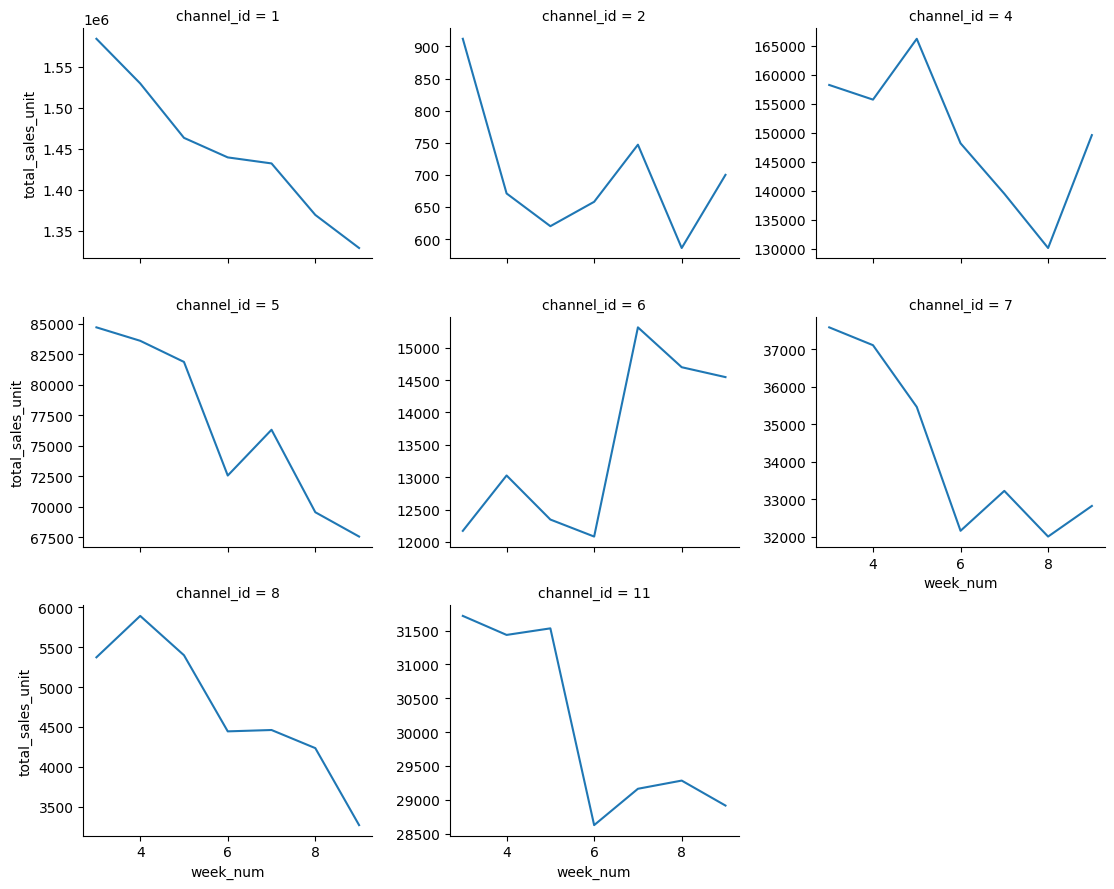

In [ ]:
channel_week = (sales.pivot_table(index = "week_num", columns = "channel_id", values = "sales_units", aggfunc = "sum")
                .reset_index().melt(id_vars = "week_num", var_name = "channel_id", value_name = "total_sales_unit") )



sns.relplot(channel_week, x = "week_num", y = "total_sales_unit", col = "channel_id",
            kind = "line", col_wrap = 3,height = 3, aspect = 1.25, facet_kws = {"sharey": False})

plt.tight_layout()
plt.show()

Sales, Return, Adjusted Demand VS Channels

- Channel 1 commands the overwhelming majority of network volume and transaction frequency
- Channel 5 generates a massive, disproportionate volume of expired returns relative to its total sales
- variance observed across the sales channel
- sales channel 5 - has the highest mean demand
- All the channel sales demand - decreasing over the week - except for channel 6 which shows a increasing trend.

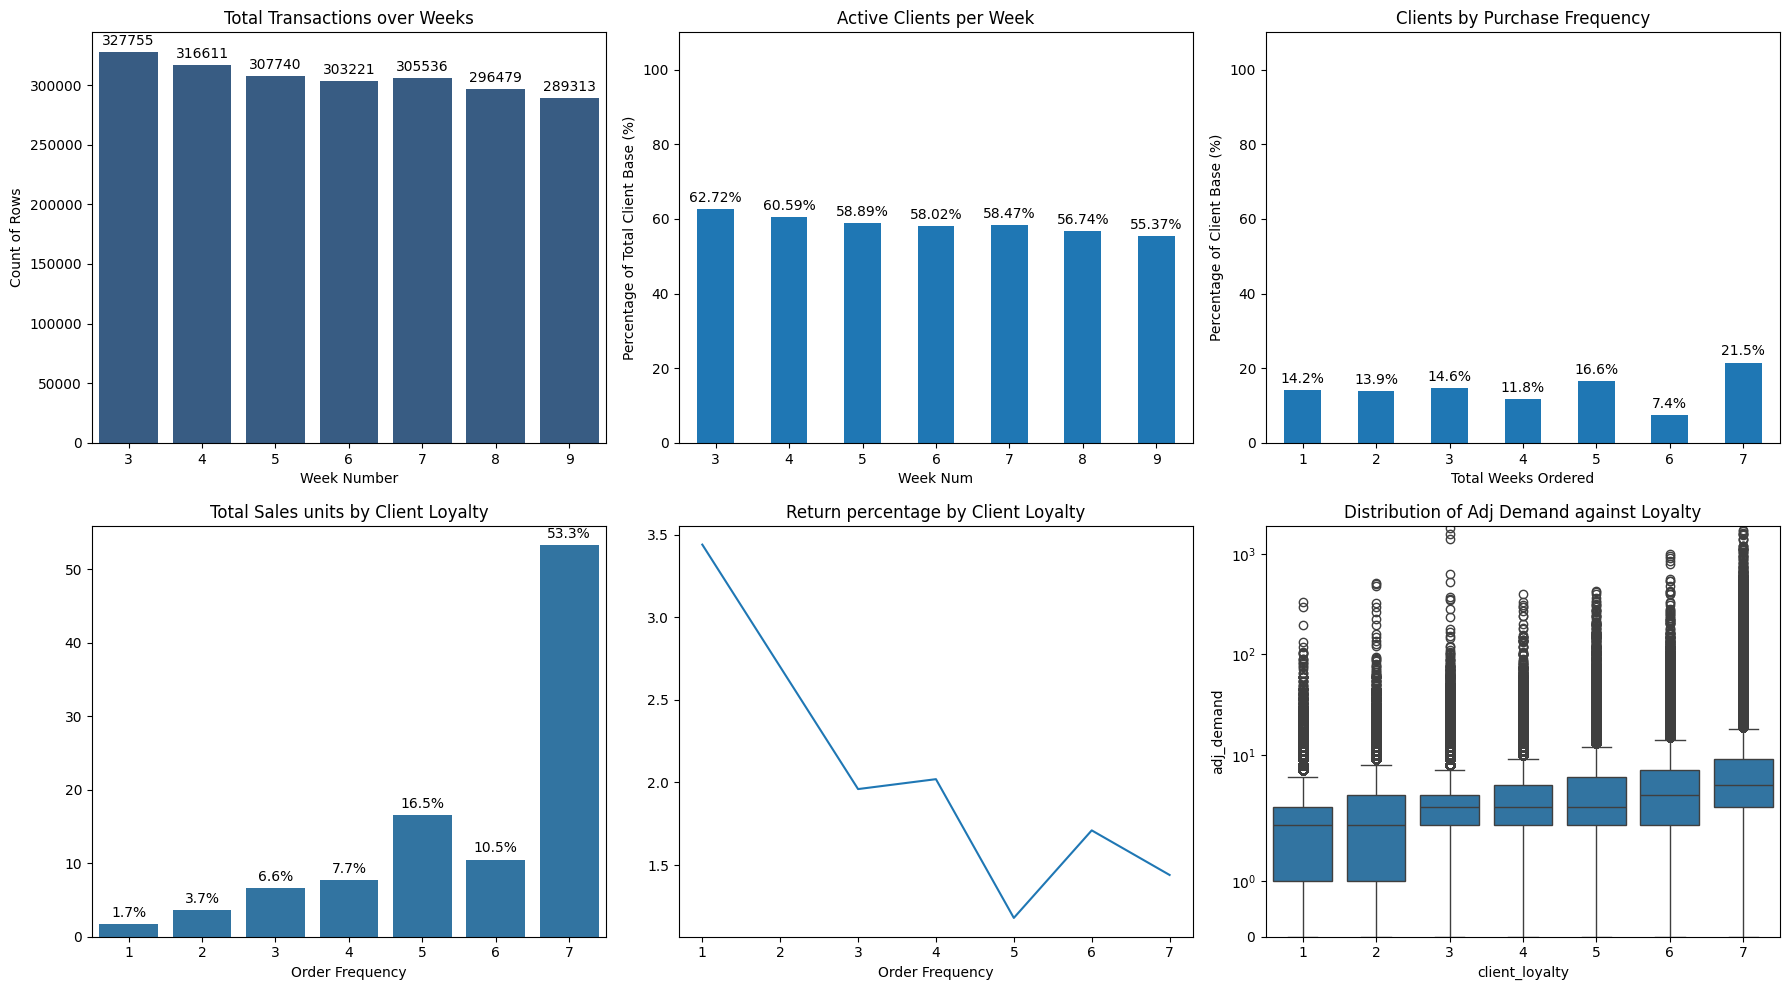

In [ ]:
fig, axes = plt.subplots(ncols = 3, nrows =2, figsize = (18,10))
axes = axes.flatten()

sns.countplot(data=sales, x="week_num", ax=axes[0], color="#2b5c8f")
axes[0].set_title("Total Transactions over Weeks")
axes[0].set_xlabel("Week Number")
axes[0].set_ylabel("Count of Rows")
axes[0].bar_label(axes[0].containers[0], padding=3)

(sales.groupby("week_num")["client_id"].nunique()*100/ sales["client_id"].nunique()).plot(
    kind = "bar",
    ax = axes[1]
)
axes[1].set_title("Active Clients per Week")
axes[1].set_xlabel("Week Num")
axes[1].set_ylabel("Percentage of Total Client Base (%)")
axes[1].tick_params(axis='x', rotation=0) # Correct way to fix rotation on an axis
# Add labels for Plot 2
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", padding=3)



(sales.groupby("client_id")["week_num"].nunique().value_counts(normalize=True) * 100).sort_index().plot(
    kind="bar",
    ax = axes[2]

)

axes[2].set_title("Clients by Purchase Frequency")
axes[2].set_xlabel("Total Weeks Ordered")
axes[2].set_ylabel("Percentage of Client Base (%)")
axes[2].tick_params(axis='x', rotation=0)
# Add labels for Plot 3
axes[2].bar_label(axes[2].containers[0], fmt="%.1f%%", padding=3)

# Set common y-limits for the percentage plots to make them comparable
axes[1].set_ylim(0, 110)
axes[2].set_ylim(0, 110)


# Calculate total network sales first
total_sales = sales['sales_units'].sum()

# Define a function that divides the sum of the current slice by the global total
def percent_of_total(x):
    return (x.sum() / total_sales) * 100
sns.barplot(sales, y = "sales_units", x = "client_loyalty", estimator = percent_of_total,
            ax = axes[3], errorbar = None)
axes[3].set_title("Total Sales units by Client Loyalty")
axes[3].set_xlabel("Order Frequency")
axes[3].set_ylabel("")
axes[3].bar_label(axes[3].containers[0], fmt="%.1f%%", padding=3)

return_prop = sales.groupby("client_loyalty")[["sales_units", "return_units"]].sum().reset_index()
return_prop["return_percn"] = ((return_prop["return_units"] / return_prop["sales_units"])*100).round(2)

sns.lineplot(return_prop, x = "client_loyalty", y = "return_percn", ax = axes[4])
axes[4].set_title("Return percentage by Client Loyalty")
axes[4].set_xlabel("Order Frequency")
axes[4].set_ylabel("")


sns.boxplot(sales, x = "client_loyalty", y = "adj_demand", ax = axes[5])
axes[5].set_title("Distribution of Adj Demand against Loyalty")
axes[5].set_yscale("symlog")
axes[5].set_ylim(bottom = 0)

plt.tight_layout(h_pad = 1.25, w_pad = 1.25)
plt.show()

Order VS Week VS client loyalty.
- 42% of the clients order than 3 times in a week.
- The less frequency clients have highest return percentage.
- at any time min 55% of the clients are actively ordering and max of 63%.
- highly loyal(frequent clients--> 6 and 7) contributes 64% of the sales volume.
- Observable variance in adj_demand across client_loyalty

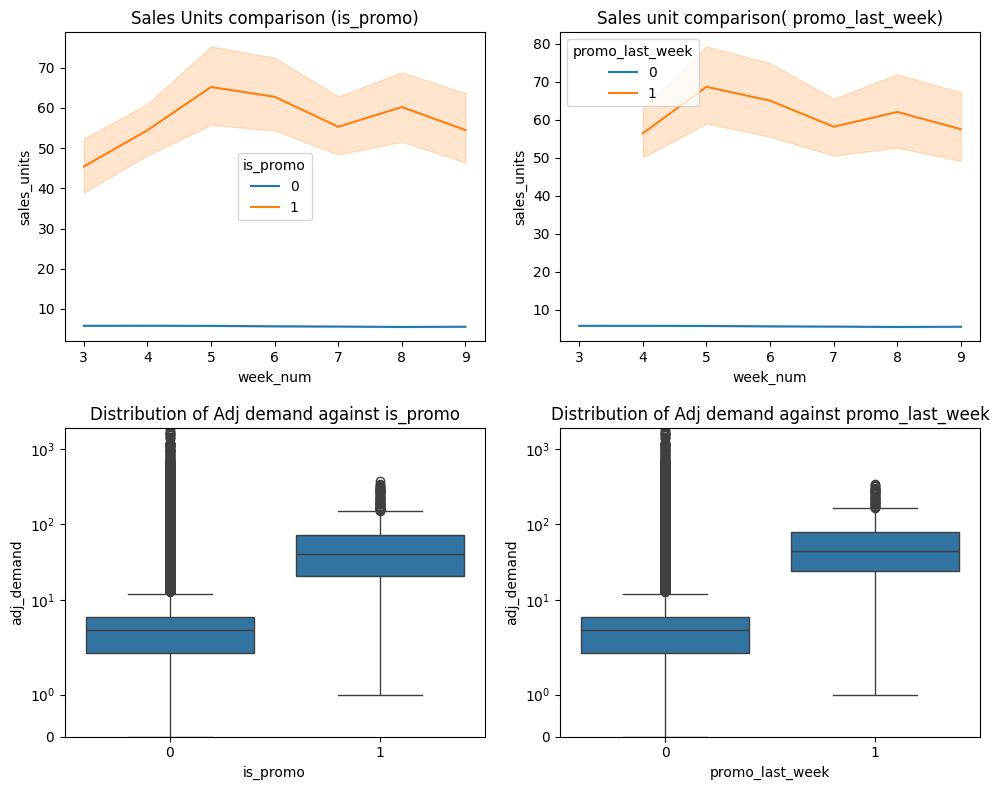

In [ ]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10,8))

axes = axes.flatten()

sns.lineplot(sales, x = "week_num", y = "sales_units", hue = "is_promo", ax = axes[0])
axes[0].set_title("Sales Units comparison (is_promo)")

sns.lineplot(sales, x = "week_num", y = "sales_units", hue = "promo_last_week", ax = axes[1])
axes[1].set_title("Sales unit comparison( promo_last_week)")

sns.boxplot(sales, x = "is_promo", y = "adj_demand", ax = axes[2])
axes[2].set_title("Distribution of Adj demand against is_promo")
axes[2].set_yscale("symlog")
axes[2].set_ylim(bottom = 0)

sns.boxplot(sales, x = "promo_last_week", y = "adj_demand", ax = axes[3])
axes[3].set_title("Distribution of Adj demand against promo_last_week")
axes[3].set_yscale("symlog")
axes[3].set_ylim(bottom = 0)



plt.tight_layout(h_pad = 1.5, w_pad = 1.5)
plt.show()

Promotion
- Shows a clear - demand variance in anticipation of the promotion.
- Higher mean sales compared to without promo
- Adj_demand box plots against promotional events show are clear variance between the two groups----> thus proving that we have successfully and meaningfully split the data

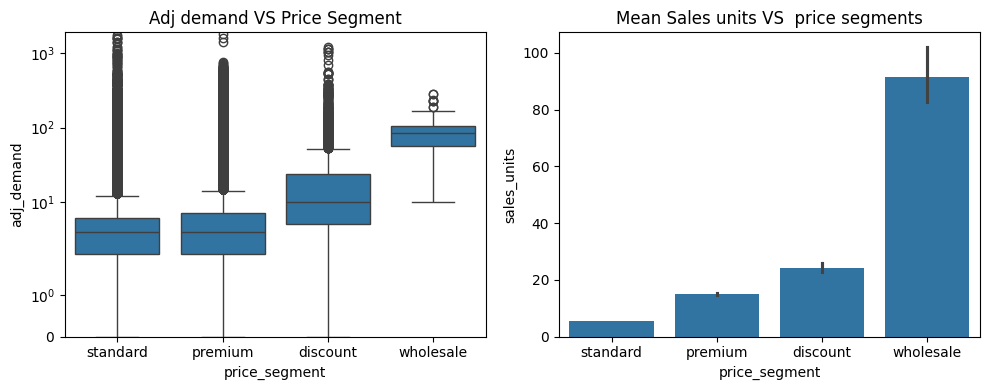

In [ ]:
fig,axes = plt.subplots(ncols =2, nrows = 1, figsize = (10,4) )

sns.boxplot(sales, x = "price_segment", y = "adj_demand", ax = axes[0])
axes[0].set_title("Adj demand VS Price Segment")
axes[0].set_yscale("symlog")
axes[0].set_ylim(bottom = 0)

sns.barplot(sales, x = "price_segment", y = "sales_units", ax = axes[1])
axes[1].set_title("Mean Sales units VS  price segments")

plt.tight_layout(h_pad = 1.25, w_pad = 1.25)
plt.show()



Price segment-
- Asj demand shows are clear distribution gap(variance) across the price segment. Making it a meaningfull split.
- Wholesales shows a much higher mean average scaler as compared to others in the segments.

## EDA Synthesis — Modeling Decisions

1. Target variable
- Adjusted demand is right-skewed (median 4, max 1,815). Raw-scale modeling would be dominated by high-volume deliveries if not transformed.

- If left un-transformed, a model optimizing for RMSE (Root Mean Squared Error) - will heavily penalize errors on the 1,800-unit orders, compromising its accuracy on the millions of 5-unit orders. The log transformation forces the model to care about relative percentage error rather than absolute unit error.

2. Feature viability
- Four columns — `sales_units`, `sales_pesos`, `return_units`, `return_pesos` —
are computed alongside the target and constitute direct leakage. They
remain valuable as *sources* for lagged and aggregated features but
cannot enter the model as current-week values.

3. Categorical strategy
- Client cardinality (521k) rules out one-hot encoding. Combined with
sparsity (only 21% of clients appear in all 7 weeks), this forces a shift
from per-entity encoding to *aggregation-based features*: historical mean
demand per client, per route, per depot. These aggregations must be
computed on data strictly preceding the row's week to prevent leakage.

4. Validation strategy
- Random KFold is inappropriate. Weeks 3-7 will serve as training data,
weeks 8-9 as holdout.

5. Tri-Point Promotional Encoding (Lead/Current/Lag)

- The "Demand Wave" plots showed significant variance in demand before, during, and after a promotion.
- These three columns give the model "Time-Series Memory" without risking data leakage.

6. Categorical Price Segmentation
- Boxplots confirmed that "Wholesale" clients have a completely disjointed distribution of demand compared to "Standard" clients.
- price_segment acts as a high-value categorical feature.
-




In [ ]:
sales.head()

,week_num,depot_id,channel_id,route_id,client_id,sales_units,sales_pesos,return_units,return_pesos,adj_demand,client_loyalty,cost_unit,price_segment,is_promo,promo_last_week
0,5,2095,11,3906,215,3,25.14,0,0.0,3,1,8.38,standard,0,0
1,3,1227,1,1234,772,10,83.80,0,0.0,10,3,8.38,standard,0,0
2,6,1227,1,1234,772,3,25.14,0,0.0,3,3,8.38,standard,0,0
3,7,1227,1,1234,772,5,41.90,0,0.0,5,3,8.38,standard,0,0
4,3,1227,1,1263,786,6,50.28,0,0.0,6,4,8.38,standard,0,0


# **Modelling Preparation**

***Train/Validation split***

In [ ]:
sales = sales.sort_values(by = ["client_id", "week_num"])

print(f"Weeks -- {sales["week_num"].sort_values().unique()}")

train_df = sales.loc[sales["week_num"] <= 7].copy()
val_df = sales.loc[sales["week_num"] >= 8].copy()

print(f"Shape of Train df {train_df.shape}")
print(f"shape of Validation df {val_df.shape}")

train_df = train_df.sort_values(by = ["client_id", "week_num"])
val_df = val_df.sort_values(by = ["client_id", "week_num"])

Weeks -- [3 4 5 6 7 8 9]
Shape of Train df (1560863, 15)
shape of Validation df (585792, 15)


Data not split using normal train_test_split - because the future data can leak into train df, which can lead to data-leakage(time ahead bias)

Result of data leakage - the most dangerous pitfalls in machine learning because it creates the illusion of a perfect model. Your model will show incredibly high accuracy (e.g., 99%) during training and testing, but the moment you deploy it into the real world, it will fail miserably because that "future" data is no longer available to it.

***Feature Engineering***

In [ ]:
map_dict = {
    "client_id": "route_id",
    "route_id": "depot_id",
    "depot_id" : "channel_id"
}

# calculating means from train_df
# mapping mean values to train and val df

for child in (list(map_dict.keys()) + ["channel_id"]):
    mean_col_name = f"{child.split('_')[0]}_mean"

    # Calculate the mean from training data
    mean_series = train_df.groupby(child)["adj_demand"].mean().round(3)

    # Map to Train
    train_df[mean_col_name] = train_df[child].map(mean_series)

    # Map to Val (using the training means!)
    val_df[mean_col_name] = val_df[child].map(mean_series)

# Hierarchical fillna in val_df
# fill nan values with global_mean

for child, parent in map_dict.items():
    child_col = f"{child.split('_')[0]}_mean"
    parent_col = f"{parent.split('_')[0]}_mean"

    # Fill the child NaNs with the parent averages
    val_df[child_col] = val_df[child_col].fillna(val_df[parent_col]).fillna(train_df["adj_demand"].mean())

# check for missing values
for child in map_dict.keys():
    col = f"{child.split('_')[0]}_mean"
    print(f"Missing values in {col}: {val_df[col].isna().sum()}")

train_check = train_df[['client_mean', 'route_mean', 'depot_mean', 'channel_mean', 'client_loyalty']].isna().sum()
print(f"Train NaN check (should all be 0):\n{train_check}")

Missing values in client_mean: 0
Missing values in route_mean: 0
Missing values in depot_mean: 0
Train NaN check (should all be 0):
client_mean       0
route_mean        0
depot_mean        0
channel_mean      0
client_loyalty    0
dtype: int64


In [ ]:
# client_loyalty is leaking future data - as it was calculated all rows

loyalty = train_df.groupby("client_id")["week_num"].nunique()
train_df["client_loyalty"] = train_df["client_id"].map(loyalty)
val_df["client_loyalty"] = val_df["client_id"].map(loyalty).fillna(0).astype("int8")

 Unique values in depot_id : 376

 Unique values in channel_id : 8

 Unique values in route_id : 818

 Unique values in client_id : 521786



"The dataset exhibits high cardinality across several key features: depot_id (376 unique values), route_id (818), and client_id (521,786). One-hot encoding these features is computationally infeasible — it would produce a sparse matrix of over 500,000 columns and introduce the curse of dimensionality. Instead, we encode these entities through aggregation features: the historical mean of adj_demand at each level (client, route, depot, channel), computed on training data only. These continuous features condense each entity's identity into a summary of its past behavior, letting the model benefit from entity-specific signal without the explosion in dimensionality."

***Feature Selection***

In [ ]:
# cols to keep

tgt_col = "adj_demand"
keep_cols = ['week_num','channel_id', 'client_loyalty','price_segment',
            'is_promo', 'promo_last_week', 'client_mean',
            'route_mean','depot_mean', 'channel_mean']

num_cols = ['week_num', 'client_loyalty','is_promo', 'promo_last_week', 'client_mean',
            'route_mean','depot_mean', 'channel_mean']

cat_cols = ['channel_id','price_segment']

x_train  = train_df[keep_cols].copy()
y_train = np.log1p(train_df["adj_demand"])

x_val = val_df[keep_cols].copy()
y_val = np.log1p(val_df["adj_demand"])


In [ ]:
# checks

print(f"X_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {x_val.shape}, y_val: {y_val.shape}")
print(f"\nFeature columns: {x_train.columns.tolist()}")
print(f"\nDtypes:\n{x_train.dtypes}")
print(f"\nNaN check — X_train: {x_train.isna().sum().sum()}, X_val: {x_val.isna().sum().sum()}")
print(f"NaN check — y_train: {y_train.isna().sum()}, y_val: {y_val.isna().sum()}")

X_train: (1560863, 10), y_train: (1560863,)
X_val:   (585792, 10), y_val: (585792,)

Feature columns: ['week_num', 'channel_id', 'client_loyalty', 'price_segment', 'is_promo', 'promo_last_week', 'client_mean', 'route_mean', 'depot_mean', 'channel_mean']

Dtypes:
week_num             int64
channel_id           int64
client_loyalty       int64
price_segment       object
is_promo              int8
promo_last_week       int8
client_mean        float64
route_mean         float64
depot_mean         float64
channel_mean       float64
dtype: object

NaN check — X_train: 0, X_val: 0
NaN check — y_train: 0, y_val: 0


# **Models**

In [ ]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ],
    remainder='drop'  # explicit: anything not listed gets dropped
)

models = {
    'ridge': Ridge(alpha=1.0),
    'lgbm':  LGBMRegressor(verbose=-1, random_state=42),
}

m1_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('pre', preprocessor),
        ('model', model),
    ])

    pipeline.fit(x_train, y_train)


    y_pred_train = pipeline.predict(x_train)
    y_pred_val   = pipeline.predict(x_val)

    m1_results.append({
        'model':     name,
        'r2_train':  pipeline.score(x_train, y_train),
        'r2_val':    pipeline.score(x_val, y_val),
        'rmsle_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'rmsle_val':   np.sqrt(mean_squared_error(y_val, y_pred_val)),
    })

m1_df = pd.DataFrame(m1_results)
print(m1_df.round(4))



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   model  r2_train  r2_val  rmsle_train  rmsle_val
0  ridge    0.3783  0.3378       0.5279     0.5495
1   lgbm    0.7380  0.4570       0.3427     0.4976


In [ ]:
# Baseline comparison

# Against Global Mean
baseline_pred = np.full(len(y_val), y_train.mean())
baseline_rmsle = np.sqrt(mean_squared_error(y_val, baseline_pred))
print(f"Global mean baseline RMSLE: {baseline_rmsle:.4f}")

# Against Client Mean
client_mean_pred = np.log1p(x_val['client_mean'])
client_mean_rmsle = np.sqrt(mean_squared_error(y_val, client_mean_pred))
print(f"Client-mean lookup baseline RMSLE: {client_mean_rmsle:.4f}")

Global mean baseline RMSLE: 0.6762
Client-mean lookup baseline RMSLE: 0.5118


"A client-mean lookup achieves RMSLE 0.512 with zero modeling — just a groupby. Ridge, despite 10 features and proper preprocessing, performed worse than this baseline. LightGBM marginally improved on it (0.498). The dominant signal in this dataset is client identity; additional features contribute little marginal information."

Reason:
- Model penalized the client_average and other features arent that important( isnt able to build non_collinear relationship)
- Mean features arent log transformed - the smaller (high count) values are distorting the model.

In [ ]:
# Build a secondary ridge model - with log transformed means

preprocessor_ridge = ColumnTransformer(transformers = [
    ("log", Pipeline([("log", FunctionTransformer(np.log1p)), ("scaler", StandardScaler())]), ["client_mean", "route_mean", "depot_mean", "channel_mean"]),
    ("scaler", StandardScaler(), ["client_loyalty", "week_num", "is_promo", "promo_last_week"]),
    ("dummy", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder = "passthrough")


pipeline_ridge = Pipeline([
    ("scale", preprocessor_ridge),
    ("model", Ridge())
])

pipeline_ridge.fit(x_train, y_train)

ridge_result = []

ridge_result.append({
    "model" : "Ridge(log)",
    "r2_train": np.round(pipeline_ridge.score(x_train, y_train),4),
    "r2_val" : np.round(pipeline_ridge.score(x_val, y_val),4),
    "rmsle_train" : np.sqrt(mean_squared_error(y_train, pipeline_ridge.predict(x_train))).round(3),
    "rmsle_val" : np.sqrt(mean_squared_error(y_val, pipeline_ridge.predict(x_val))).round(4)
})

print(ridge_result)

[{'model': 'Ridge(log)', 'r2_train': np.float64(0.7358), 'r2_val': np.float64(0.4616), 'rmsle_train': np.float64(0.344), 'rmsle_val': np.float64(0.4955)}]


In [ ]:
# 1. Update the list (This modifies m1_results in the background)
m1_results.append(ridge_result[0])

# 2. Feed the updated list into Pandas
results_df = pd.DataFrame(m1_results)
results_df

,model,r2_train,r2_val,rmsle_train,rmsle_val
0,ridge,0.378343,0.337800,0.527893,0.549544
1,lgbm,0.738032,0.457035,0.342685,0.497615
2,Ridge(log),0.735800,0.461600,0.344000,0.495500


Ridge went from RMSLE 0.550 to 0.496. A single preprocessing change — log-transforming four skewed features — improved validation performance by 10%. Ridge is now essentially tied with LightGBM (0.498), and it beats the client-mean baseline (0.512) by a meaningful margin.

In [ ]:
# how does a simple lgbm performs - no scaling

lgbm = LGBMRegressor()

x_lgbm_train = x_train.copy()
x_lgbm_val = x_val.copy()

category_cols = ["week_num", "channel_id", "price_segment", "client_loyalty"]

for col in category_cols:
  x_lgbm_train[col] = x_lgbm_train[col].astype("category")
  x_lgbm_val[col] =  x_lgbm_val[col].astype("category")


lgbm.fit(x_lgbm_train, y_train)

lgbm_result = []

lgbm_result.append({
    "model" : "lgbm(no_scaling)",
    "r2_train": np.round(lgbm.score(x_lgbm_train, y_train),4),
    "r2_val" : np.round(lgbm.score(x_lgbm_val, y_val),4),
    "rmsle_train" : np.sqrt(mean_squared_error(y_train, lgbm.predict(x_lgbm_train))).round(3),
    "rmsle_val" : np.sqrt(mean_squared_error(y_val, lgbm.predict(x_lgbm_val))).round(4)
})

In [ ]:
m1_results.append(lgbm_result[0])

results_df = pd.DataFrame(m1_results)
results_df

,model,r2_train,r2_val,rmsle_train,rmsle_val
0,ridge,0.378343,0.337800,0.527893,0.549544
1,lgbm,0.738032,0.457035,0.342685,0.497615
2,Ridge(log),0.735800,0.461600,0.344000,0.495500
3,lgbm(no_scaling),0.738100,0.463500,0.343000,0.494600


### M1 Results — Feature Engineering vs Model Choice

| Model | val RMSLE | Notes |
|-------|-----------|-------|
| Global mean baseline | 0.676 | Predicts constant; establishes floor |
| Client-mean baseline | 0.512 | Groupby lookup; no model |
| Ridge (raw features) | 0.550 | Worse than lookup baseline |
| Ridge (log features) | **0.496** | log1p on skewed features |
| LightGBM | **0.498** | Default hyperparameters |

**Key findings:**

1. **Client identity dominates.** The client-mean baseline (0.512 RMSLE) already captures
   most of the predictable variance. Any model that fails to beat this baseline is
   not earning its complexity.

2. **Preprocessing > model choice, on this data.** A single preprocessing change
   (log1p on skewed aggregation features) moved Ridge from 0.550 to 0.496 — a larger
   improvement than switching from Ridge to LightGBM. The dominant shape in the data
   is log-linear, and log-transforming features allows a linear model to capture it.

3. **Ridge and LightGBM perform near-identically (0.496 vs 0.498)** after
   appropriate preprocessing. This suggests the feature-target relationships are
   largely additive in log space, with few genuine non-linear interactions for the
   tree model to exploit.

4. **Both models overfit similarly** (~0.15 RMSLE gap between train and val).
   Regularization would narrow this; tuning is deferred to after the M1/M2 comparison.

5. **LightGBM is scale-invariant.** Tested with and without StandardScaler;
   difference was 0.003 RMSLE (noise-level). Confirms that tree-based models
   do not benefit from feature scaling.

# **M2 Model**
- Adding more features to the df - check for r2 and rmsle
- Adding client_std, client_median, route_std

In [ ]:
map_dict2 = {
    "client_id": "route_id",
    "route_id": "depot_id",
}

# std cols - client and route
# drop the depot_std later

std_cols = ["client_id", "route_id", "depot_id"]

for col in std_cols:
  col_name = f"{col.split('_')[0]}_std"
  std_series = train_df.groupby(col)["adj_demand"].std()
  train_df[col_name] = train_df[col].map(std_series)
  val_df[col_name] = val_df[col].map(std_series)

# Hierarchical fillna in val_df
# fill nan values with global_mean

for child, parent in map_dict2.items():
  child_col = f"{child.split('_')[0]}_std"
  parent_col = f"{parent.split('_')[0]}_std"

  val_df[child_col] = val_df[child_col].fillna(val_df[parent_col]).fillna(train_df["adj_demand"].std())


# median col - Client

median_series = train_df.groupby("client_id")["adj_demand"].median()

train_df["client_median"] = train_df["client_id"].map(median_series)
val_df["client_median"] = val_df["client_id"].map(median_series).fillna(train_df["adj_demand"].median())

# sanity check

new_cols = ["client_std", "route_std", "client_median"]



In [ ]:
new_cols = ["client_std", "route_std", "client_median"]
for col in new_cols:
  print(f"missing values in {col} \n train_df : {train_df[col].isna().sum()} \n val_df : {val_df[col].isna().sum()}")

# 95169 clients - placed order excatly once

missing values in client_std 
 train_df : 95169 
 val_df : 0
missing values in route_std 
 train_df : 4 
 val_df : 0
missing values in client_median 
 train_df : 0 
 val_df : 0


In [ ]:
print(train_df[train_df["route_std"] == 0])

# std ==0 because both the entries for the route are same

train_df["route_std"] = train_df["route_std"].fillna(0)

         week_num  depot_id  channel_id  route_id  client_id  sales_units  \
1762243         4      1143           8      3425    4299937            2   
1793436         4      1143           8      3425    4344485            2   
2084175         3      2099           2      1522    5958920           15   
2084176         6      2099           2      1522    5958920           15   

         sales_pesos  return_units  return_pesos  adj_demand  ...  is_promo  \
1762243        16.76             0           0.0           2  ...         0   
1793436        16.76             0           0.0           2  ...         0   
2084175       123.45             0           0.0          15  ...         0   
2084176       123.45             0           0.0          15  ...         0   

         promo_last_week client_mean  route_mean  depot_mean  channel_mean  \
1762243                0         2.0         2.0      11.547        30.538   
1793436                0         2.0         2.0      11.547  

In [ ]:
train_df["client_std"] = train_df["client_std"].fillna(0)

new_cols = ["client_std", "route_std", "client_median"]
for col in new_cols:
  print(f"missing values in {col} \n train_df : {train_df[col].isna().sum()} \n val_df : {val_df[col].isna().sum()}")

missing values in client_std 
 train_df : 0 
 val_df : 0
missing values in route_std 
 train_df : 0 
 val_df : 0
missing values in client_median 
 train_df : 0 
 val_df : 0


In [ ]:
cols_keep = ['week_num','client_loyalty','price_segment','is_promo','channel_id',
             'promo_last_week', 'client_mean', 'route_mean',
             'depot_mean', 'client_std','channel_mean', 'route_std','client_median']

x2_train = train_df[cols_keep].copy()
y2_train = np.log1p(train_df["adj_demand"])

x2_val = val_df[cols_keep].copy()
y2_val = np.log1p(val_df["adj_demand"])

In [ ]:
# checks

print(f"X_train: {x2_train.shape}, y_train: {y2_train.shape}")
print(f"X_val:   {x2_val.shape}, y_val: {y2_val.shape}")
print(f"\nFeature columns: {x2_train.columns.tolist()}")
print(f"\nDtypes:\n{x2_train.dtypes}")
print(f"\nNaN check — X_train: {x2_train.isna().sum().sum()}, X_val: {x2_val.isna().sum().sum()}")
print(f"NaN check — y_train: {y2_train.isna().sum()}, y_val: {y2_val.isna().sum()}")

X_train: (1560863, 13), y_train: (1560863,)
X_val:   (585792, 13), y_val: (585792,)

Feature columns: ['week_num', 'client_loyalty', 'price_segment', 'is_promo', 'channel_id', 'promo_last_week', 'client_mean', 'route_mean', 'depot_mean', 'client_std', 'channel_mean', 'route_std', 'client_median']

Dtypes:
week_num             int64
client_loyalty       int64
price_segment       object
is_promo              int8
channel_id           int64
promo_last_week       int8
client_mean        float64
route_mean         float64
depot_mean         float64
client_std         float64
channel_mean       float64
route_std          float64
client_median      float64
dtype: object

NaN check — X_train: 0, X_val: 0
NaN check — y_train: 0, y_val: 0


In [ ]:
preprocessor_m2 = ColumnTransformer(transformers = [
    ("log", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("scaler", StandardScaler())]), ["client_mean", "route_mean", "depot_mean","channel_mean", "client_std", "route_std", "client_median"]),
    ("scaler", StandardScaler(), ["client_loyalty", "week_num", "is_promo", "promo_last_week"]),
    ("dummy", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder = "passthrough")

model2 = {
    "ridge": Ridge(),
    "lgbm" : LGBMRegressor()
}

m2_results = []

for name, model in model2.items():
  pipeline2 = Pipeline([("scaler", preprocessor_m2), ("model", model)])

  pipeline2.fit(x2_train, y2_train)
  m2_results.append({
        'model':     name,
        'r2_train':  pipeline2.score(x2_train, y2_train),
        'r2_val':    pipeline2.score(x2_val, y2_val),
        'rmsle_train': np.sqrt(mean_squared_error(y2_train, pipeline2.predict(x2_train))),
        'rmsle_val':   np.sqrt(mean_squared_error(y2_val, pipeline2.predict(x2_val))),
    })



m2_df = pd.DataFrame(m2_results)
print(m2_df.round(4))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   model  r2_train  r2_val  rmsle_train  rmsle_val
0  ridge    0.7406  0.4629       0.3410     0.4949
1   lgbm    0.7469  0.4466       0.3368     0.5024


In [ ]:
# Feature importance from the LightGBM M2 model
lgbm_pipeline = Pipeline([("pre", preprocessor_m2), ("model", LGBMRegressor())])
lgbm_pipeline.fit(x2_train, y2_train)

# Extract feature names after preprocessing
preprocessor_fitted = lgbm_pipeline.named_steps['pre']
feature_names = preprocessor_fitted.get_feature_names_out()

# Extract importances from the fitted LightGBM
importances = lgbm_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

                          feature  importance
0                log__client_mean         825
4                 log__client_std         822
8                scaler__week_num         338
6              log__client_median         310
2                 log__depot_mean         281
1                 log__route_mean         146
5                  log__route_std         135
7          scaler__client_loyalty          59
3               log__channel_mean          18
13            dummy__channel_id_4          15
9                scaler__is_promo          12
19  dummy__price_segment_discount          10
21  dummy__price_segment_standard          10
10        scaler__promo_last_week           7
20   dummy__price_segment_premium           6


"M2 features rank high in tree importance but do not improve validation performance. This suggests the features provide fit but not generalization — likely a combination of redundancy with M1 features and overfitting to noisy small-sample statistics."

### M2 Results — Enriched Aggregation Features

M2 extends M1 with three additional per-entity statistics:
- `client_std` — volatility of a client's historical demand
- `client_median` — robust central tendency (distinct from mean in skewed distributions)
- `route_std` — route-level demand volatility

| Model | M1 val RMSLE | M2 val RMSLE | Δ |
|-------|-------------|-------------|---|
| Ridge (log features) | 0.4955 | 0.4949 | −0.001 |
| LightGBM | 0.4946 | 0.5024 | +0.008 |

**Findings:**

1. **Ridge saw negligible improvement** (−0.001 RMSLE). Within noise; adding the
   enriched features did not change predictive performance measurably.

2. **LightGBM slightly degraded** (+0.008 RMSLE). Train RMSLE improved (0.343 → 0.337)
   while val RMSLE worsened, indicating the additional features enabled
   overfitting under default hyperparameters.

3. **Feature importance tells a different story than RMSLE.** `client_std` ranks as
   the second most-used feature in the M2 LightGBM model, narrowly trailing
   `client_mean` (importance 822 vs 825). `client_median` ranks fourth. Despite
   heavy usage during tree construction, these splits do not generalize to
   validation data.

4. **The feature ceiling for this feature set appears to be approximately 0.495
   RMSLE.** Additional per-client statistics describe the same underlying
   distribution as `client_mean` and do not add independent predictive signal.
   Breaking this ceiling would require fundamentally different features — lag
   features from prior weeks, interaction terms, or external data.

5. **The high importance of M2 features despite null performance impact is
   consistent with two mechanisms:** (a) redundancy — trees split on correlated
   features interchangeably, and (b) small-sample noise — `client_std` and
   `client_median` are noisy for clients with few training observations and
   introduce overfitting.

**Implication for modeling direction:** feature engineering has diminishing returns
beyond the core aggregation features. Remaining improvement will come from
regularization tuning on LightGBM and validation methodology (demonstrating the
cost of random vs time-aware CV).

***Hyperparamter tunning on M1 on LightGBM***

In [ ]:
lgbm = LGBMRegressor()

# sort train by time for TimeSeriesSplit ===
x3_train = x_train.sort_values('week_num').copy()
y3_train = y_train.loc[x3_train.index]
x3_val = x_val.copy()  # val doesn't need sort

x3_val = x_val.copy()

cat_cols_native = ['channel_id', 'price_segment']
for col in cat_cols_native:
    x3_train[col] = x3_train[col].astype('category')
    x3_val[col]   = x3_val[col].astype('category')

param_grid = {
    "n_estimators" : [100,200,500],
    "num_leaves" : [15,31,60],
    "learning_rate": [0.05, 0.1, 0.2]
}

cv = TimeSeriesSplit(n_splits = 3)

grid = GridSearchCV(lgbm, param_grid, cv = cv,
                    scoring='neg_root_mean_squared_error',
                    n_jobs = -1)

grid.fit(x3_train, y3_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'n_estimators': [100, 200, 500],
                         'num_leaves': [15, 31, 60]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print(f"Best params: {grid.best_params_}")
print(f"Best CV RMSLE: {-grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_val = best_model.predict(x3_val)
val_rmsle = np.sqrt(mean_squared_error(y_val, y_pred_val))

lgbm_tuned_result = {
    'model':       'LightGBM (tuned)',
    'best_params': grid.best_params_,
    'cv_rmsle':    -grid.best_score_,
    'r2_train':    best_model.score(x3_train, y3_train),
    'r2_val':      best_model.score(x3_val, y_val),
    'rmsle_train': np.sqrt(mean_squared_error(y3_train, best_model.predict(x3_train))),
    'rmsle_val':   val_rmsle,
}

for k, v in lgbm_tuned_result.items():
    print(f"{k}: {v}")

Best params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 15}
Best CV RMSLE: 0.3484
model: LightGBM (tuned)
best_params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 15}
cv_rmsle: 0.3483506444983128
r2_train: 0.7373974045906287
r2_val: 0.45607325084582606
rmsle_train: 0.343099403324875
rmsle_val: 0.498055718193822


In [ ]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results['cv_rmsle'] = -cv_results['mean_test_score']

top = cv_results[[
    'param_num_leaves', 'param_learning_rate', 'param_n_estimators',
    'cv_rmsle', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score').head(10)

print(top.to_string(index=False))

 param_num_leaves  param_learning_rate  param_n_estimators  cv_rmsle  std_test_score  rank_test_score
               15                 0.05                 200  0.348351        0.004374                1
               15                 0.10                 100  0.348358        0.004361                2
               31                 0.05                 200  0.348410        0.004260                3
               15                 0.10                 200  0.348415        0.004279                4
               31                 0.10                 100  0.348423        0.004286                5
               31                 0.05                 100  0.348449        0.004401                6
               60                 0.05                 100  0.348465        0.004319                7
               15                 0.05                 500  0.348468        0.004267                8
               15                 0.20                 100  0.348519        0.0042

### Hyperparameter Tuning — LightGBM on M1

Tuning used `GridSearchCV` with `TimeSeriesSplit(n_splits=3)` for CV,
preserving temporal ordering within training data.

**Grid searched:**
- `n_estimators`: [100, 200, 500]
- `num_leaves`: [15, 31, 60]
- `learning_rate`: [0.05, 0.10, 0.20]

27 combinations × 3 folds = 81 total fits.

**Best configuration:**
- `num_leaves=15, learning_rate=0.05, n_estimators=200`
- Best CV RMSLE: 0.348
- Val RMSLE: 0.498

**Key finding: tuning did not improve performance.**

The top 10 configurations produced CV RMSLE values ranging from 0.3484 to
0.3486 — a spread of 0.0002. Different configurations (num_leaves from 15
to 60, n_estimators from 100 to 500) all converged to effectively the same
performance. Fold-to-fold variance (0.004) exceeded configuration-to-
configuration variance.

This confirms the feature ceiling hypothesis established in M1/M2: the
dominant predictive signal comes from client-level aggregation features
(`client_mean` especially), and no hyperparameter configuration can
extract signal the features don't contain.

**Secondary finding: CV RMSLE (0.348) significantly underestimates true
val RMSLE (0.498).**

TimeSeriesSplit within training data evaluates 1-week-ahead forecasts
from recent history. The actual val task (weeks 8-9) requires 1-2-week-
ahead forecasts from week 7 training data. The wider forecast horizon
and distributional drift explain the 0.15 gap between internal CV and
held-out val performance. This is a known property of time-series CV
and reinforces the importance of a final held-out time-based evaluation
rather than relying on CV alone.

## Key Learnings

**1. Client identity dominates in high-cardinality transactional data.**

The client-mean lookup baseline (0.512 RMSLE) captured ~80% of the signal
any downstream model could extract. With 521,786 unique clients and only
7 weeks of history, the information content is concentrated in "what does
this specific client typically do" — not in interactions between features.
This is a generalizable insight: for any transactional dataset with
user/customer/entity-level cardinality in the hundreds of thousands, the
first line of attack is historical aggregation per entity, not feature
interaction engineering.

**2. Preprocessing choices can outweigh model selection.**

Log-transforming four skewed aggregation features (client_mean, route_mean,
depot_mean, channel_mean) moved Ridge's val RMSLE from 0.550 to 0.496 — a
larger improvement than switching from Ridge to LightGBM (0.495). The
underlying relationship is log-linear; a linear model on raw features
cannot fit a log-linear relationship, but a linear model on log features
can. When linear models underperform tree models on tabular data, the
first thing to check is feature preprocessing, not model capacity.

**3. High-cardinality categoricals require aggregation, not encoding.**

One-hot encoding 521k clients would produce a sparse matrix of infeasible
size and statistical weakness (most columns would be nonzero in 3-4 rows).
The working solution — replacing client_id with client_mean, client_std,
and client_loyalty — compresses 521k categorical values into 3 continuous
features that the model can actually learn from. This is a pattern that
generalizes to any dataset with user-level, product-level, or
transaction-level IDs.

**4. Time-based validation is non-optional for forecasting problems.**

All splits in this project respected temporal ordering: training weeks
3-7, validation weeks 8-9, with TimeSeriesSplit for cross-validation
within training. Random KFold would have mixed future data into training
folds and produced optimistically biased results. Although I did not
quantitatively demonstrate the size of this bias in this project, it's
a well-documented failure mode — and one I would demonstrate as a
follow-up experiment.

**5. Feature importance does not imply predictive value.**

In M2's LightGBM model, client_std ranked as the second most-used feature
(nearly tied with client_mean), but adding these M2 features did not
improve validation RMSLE over M1. The tree made many splits on client_std
during training, but those splits captured training-specific patterns
(noisy small-sample statistics) that didn't generalize. High importance
measures "how often a feature was useful for fit," not "how much it
improved generalization."

**6. Honest baselines expose model value.**

Without comparing to the client-mean lookup baseline, the M1 Ridge result
(0.550) might have looked like a reasonable achievement. The baseline
revealed it was worse than no modeling at all. Every supervised learning
project benefits from a 10-line lookup baseline that competing models
must beat to justify their complexity.

**7. Hyperparameter tuning reveals, but doesn't always improve.**

81 hyperparameter configurations of LightGBM produced val RMSLE values
within a 0.0002 range. This confirmed rather than improved on the default
model — but the confirmation itself is a valuable finding. When tuning
produces no meaningful improvement, the interpretation is either "the
feature ceiling is binding" (my case) or "the search space was too narrow"
(worth checking before concluding). Tuning is diagnostic, not just
optimization.

# **Next Steps**

If extending this project, I would pursue these in order of expected impact:

**1. Demonstrate the time-aware vs random-KFold gap empirically.**

**2. Add lag features from prior weeks.**

**3. Expand beyond a single product.**

**5. Introduce external data.**
